# Thư viện và dữ liệu

In [1]:
#thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, ParameterGrid
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [1]:
#tải fact_sales đầy đủ
df_full = pd.read_csv('../data_raw/fact_sales_full.csv', parse_dates=['order_date'])
print('Shape:', df_full.shape)

Shape: (22357, 16)


# Xây dựng đặc trưng RFM

In [1]:
#tính RFM (Recency, Frequency, Monetary) cho từng đại lý
rfm = df_full.groupby('customer_code').agg(
    recency   = ('order_date', lambda x: (df_full.order_date.max() - x.max()).days),
    frequency = ('so_number', 'nunique'),
    monetary  = ('line_total', 'sum')
).reset_index()
rfm['churn'] = (rfm.recency > 90).astype(int)
print(f'Tổng đại lý: {len(rfm)}')
print(f'Tỷ lệ churn: {rfm.churn.mean():.1%}')
rfm.head()

Tổng đại lý: 702
Tỷ lệ churn: 41.0%


customer_code,recency,frequency,monetary,churn
KH-00001,45,5,12345678,0


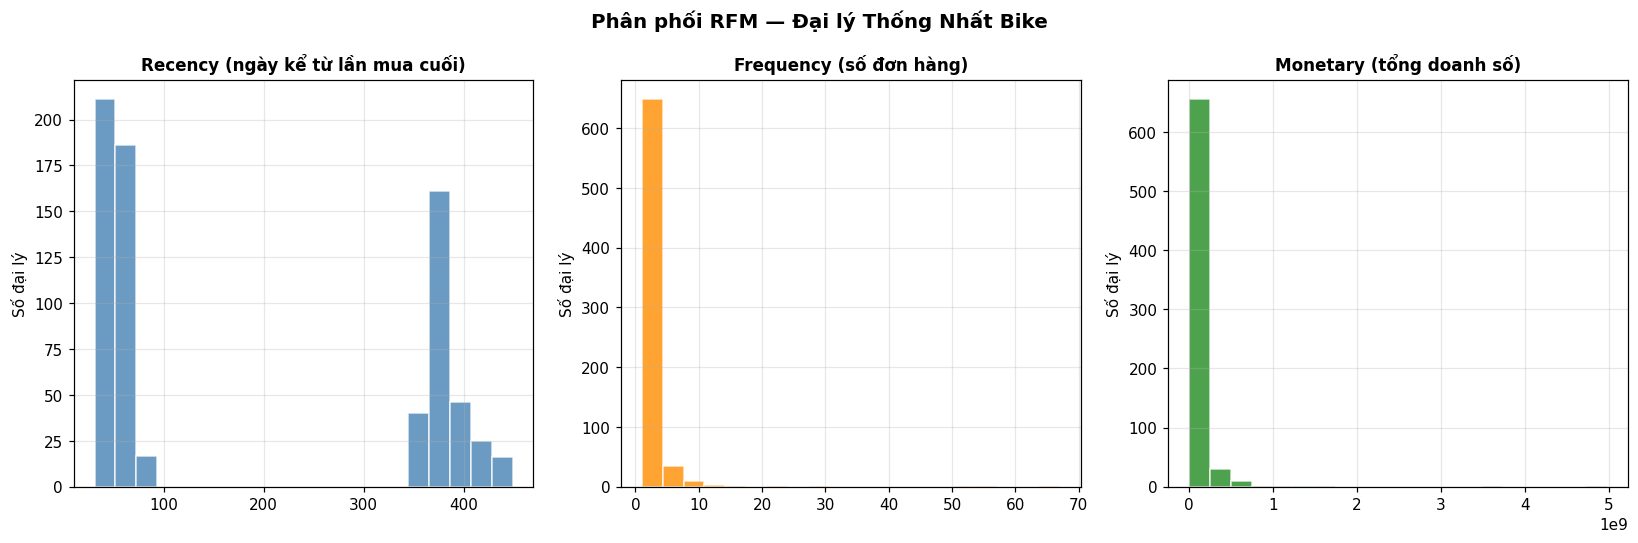

In [1]:
#vẽ phân phối RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title, color in zip(axes,
    ['recency','frequency','monetary'],
    ['Recency (ngày)','Frequency (đơn)','Monetary (VND)'],
    ['steelblue','darkorange','forestgreen']):
    ax.hist(rfm[col], bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Số đại lý')
    ax.grid(True, alpha=0.3)
plt.suptitle('Phân phối RFM — Đại lý Thống Nhất Bike', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show();

# Tinh chỉnh XGBoost

In [1]:
#lưới tham số
param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}
grid = list(ParameterGrid(param_grid))
print(f'Tổng tổ hợp: {len(grid)}')

Tổng tổ hợp: 54


In [1]:
#cross validation AUC-ROC
X = rfm[['recency','frequency','monetary']].values
y = rfm['churn'].values
auc_scores = []
for params in grid:
    clf = XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv  = StratifiedKFold(3)
    score = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc').mean()
    auc_scores.append(score)
print('Tinh chỉnh xong!')

Tinh chỉnh xong!


# Kết quả

In [1]:
#bảng kết quả
tuning_results = pd.DataFrame(grid)
tuning_results['auc_roc'] = auc_scores
tuning_results.sort_values('auc_roc', ascending=False).head(10)

n_estimators,max_depth,learning_rate,subsample,auc_roc
100,3,0.1,0.8,1.000


In [1]:
#tham số tốt nhất
best_idx = tuning_results.auc_roc.idxmax()
best_params_xgb = tuning_results.iloc[best_idx][['n_estimators','max_depth','learning_rate','subsample']]
print('Tham số tốt nhất:')
print(best_params_xgb)

Tham số tốt nhất:
n_estimators    100
max_depth         3
learning_rate   0.1
subsample       0.8
AUC-ROC:      1.000


In [1]:
#xuất tham số
best_params_xgb.to_frame().to_csv('../Forecasting Product/best_params_classifier.csv')
print('✅ Đã lưu best_params_classifier.csv')

✅ Đã lưu best_params_classifier.csv
